# 01. Exploración de Datos (EDA)

En esta etapa, nos enfocaremos en entender la naturaleza del dataset de *California Housing*.
**Objetivo:** Obtener un entendimiento de los datos, de la industria, identificar anomalías, rangos, y relaciones clave.

### Instrucciones Generales:
1. **Carga los datos:** Lee el archivo `.csv` proveniente de la carpeta `data/raw/`
2. **Inspección:** Analisis exploratorio de datos, estructura, problemas de calidad: consistencia, sensibilidad, precision y completitud.
3. **Histogramas:** Genera histogramas para cada variable numérica usando `.hist()`.
4. **Visualización Geoespacial:** Crea un gráfico de dispersión (scatter plot) usando `longitude` y `latitude`. 
   - *Tip:* Utiliza el argumento `alpha=0.2` para ver lugares de alta densidad y `c` para colorear acorde a `median_house_value`.
5. **Correlaciones:** Calcula la matriz de correlación (usando `.corr()`) de todas las variables frente a `median_house_value` para encontrar las más prometedoras y graficos de dispercion entre las variables.
6. **Concluciones**: Redactar todos los hallazgos con un lenguaje de negocio y comunicativo.

### 1. Carga de datos

In [ ]:
# Escribe tu código aquí para explorar el dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



### 2. Inspección de datos

In [11]:
# Cargar el dataset
housing = pd.read_csv("../data/interim/train_set.csv")

# Mostramos el tamaño del dataset
print(housing.shape)

(16512, 10)


In [5]:
# Validamos la informacion del dataset
print(housing.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.3+ MB
None


In [7]:
# Verficiamos la cantidad de valores nulos en cada columna
print(housing.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        168
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [26]:
# Validamos la cantidad de valores duplicados
display(housing.duplicated().sum())

np.int64(0)

In [9]:
# Imprimimos las estadisticas descriptivas del dataset
display(housing.describe())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16344.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.573125,35.637746,28.577156,2639.402798,538.949094,1425.513929,499.990189,3.870428,206333.518653
std,2.000624,2.133294,12.585738,2185.287466,423.862079,1094.795467,382.865787,1.891936,115314.047529
min,-124.350000,32.550000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.000000,296.000000,787.000000,279.000000,2.562500,119200.000000
50%,-118.510000,34.260000,29.000000,2125.000000,434.000000,1167.000000,408.000000,3.538500,179200.000000
75%,-118.010000,37.720000,37.000000,3154.000000,645.000000,1726.000000,603.000000,4.750000,263925.000000
max,-114.490000,41.950000,52.000000,39320.000000,6210.000000,16305.000000,5358.000000,15.000100,500001.000000


In [10]:
# Imprimimos las primeras filas del dataset
display(housing.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,NEAR BAY
1,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,<1H OCEAN
2,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,INLAND
3,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,INLAND
4,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,NEAR OCEAN


### 3. Histogramas

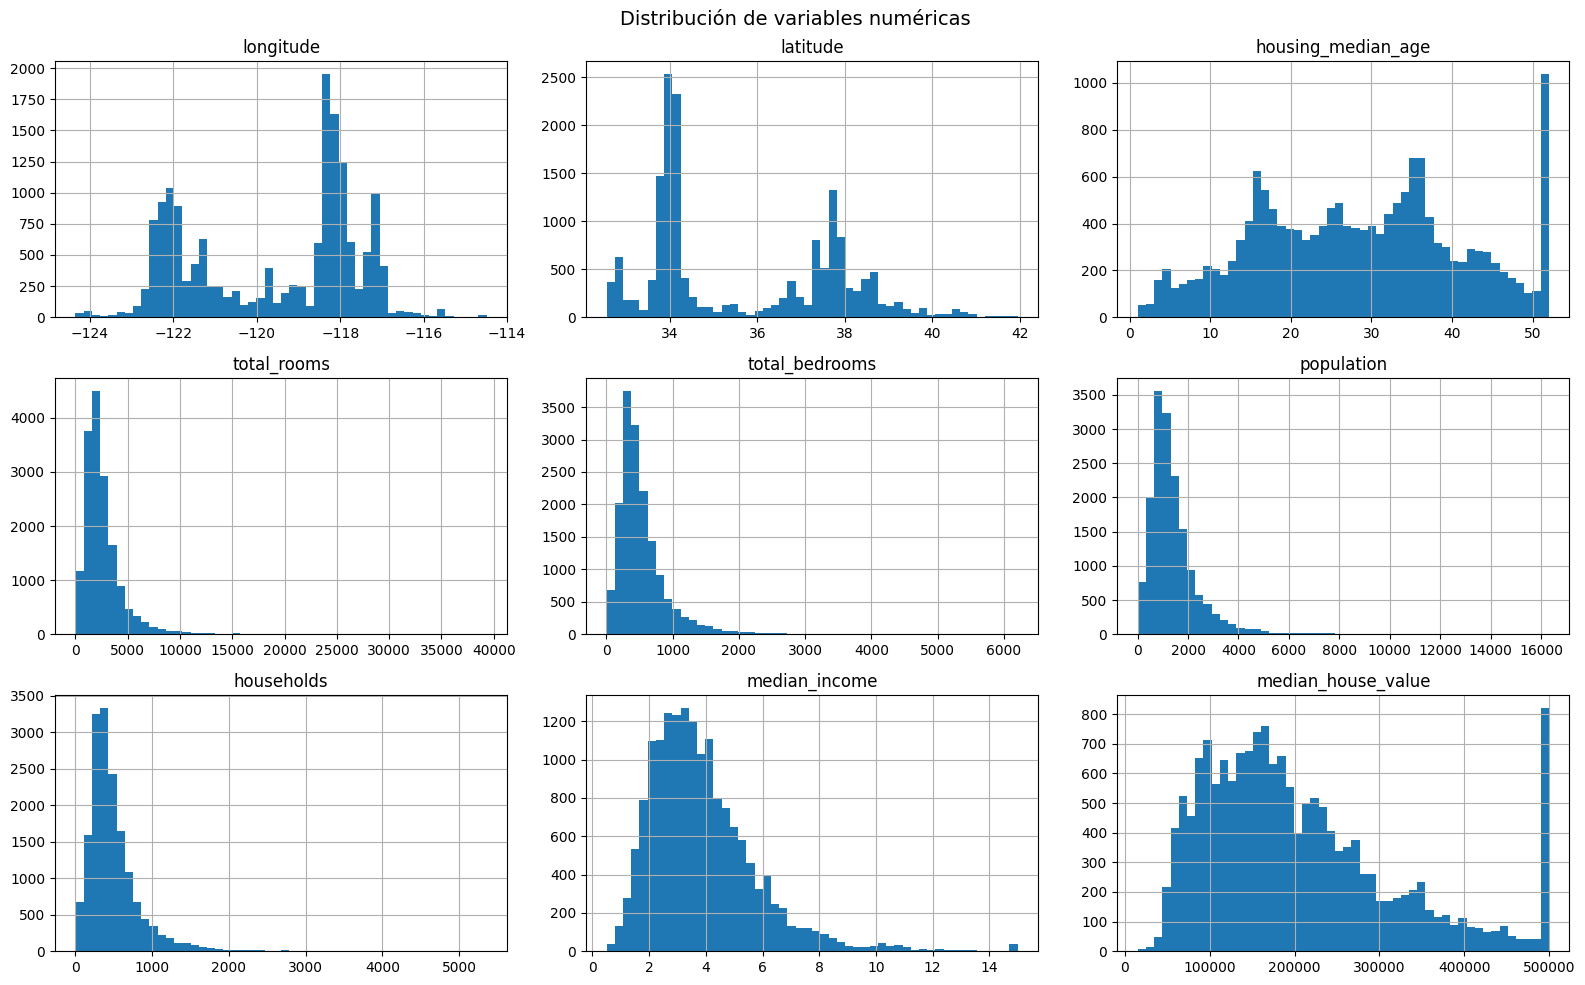

In [16]:
# Graficamos histogramas para cada variable numérica
housing.hist(bins=50, figsize=(16, 10))
plt.suptitle("Distribución de variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

### 4. Visualización Geoespacial

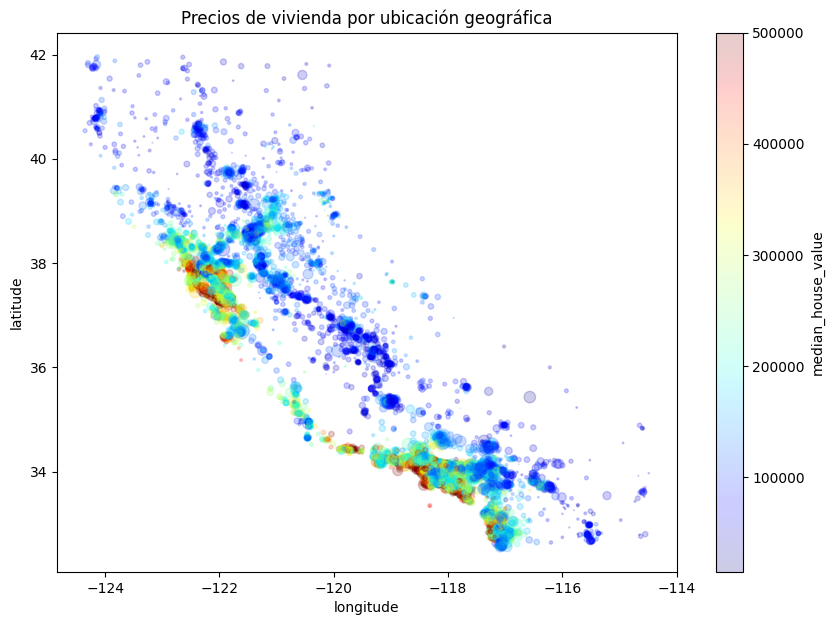

In [18]:
# Graficamos un scatter plot para visualizar la relación entre ubicación geográfica y precios de vivienda
housing.plot(
    kind="scatter",
    x="longitude", y="latitude",
    alpha=0.2,
    s=housing["population"] / 100,   # tamaño = densidad poblacional
    c="median_house_value",
    cmap="jet",
    colorbar=True,
    figsize=(10, 7)
)
plt.title("Precios de vivienda por ubicación geográfica")
plt.show()

### 5. Correlaciones

In [21]:
# Calculamos la matriz de correlacion en funcion de la variable objetivo "median_house_value"
corr_matrix = housing.corr(numeric_only=True)
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64


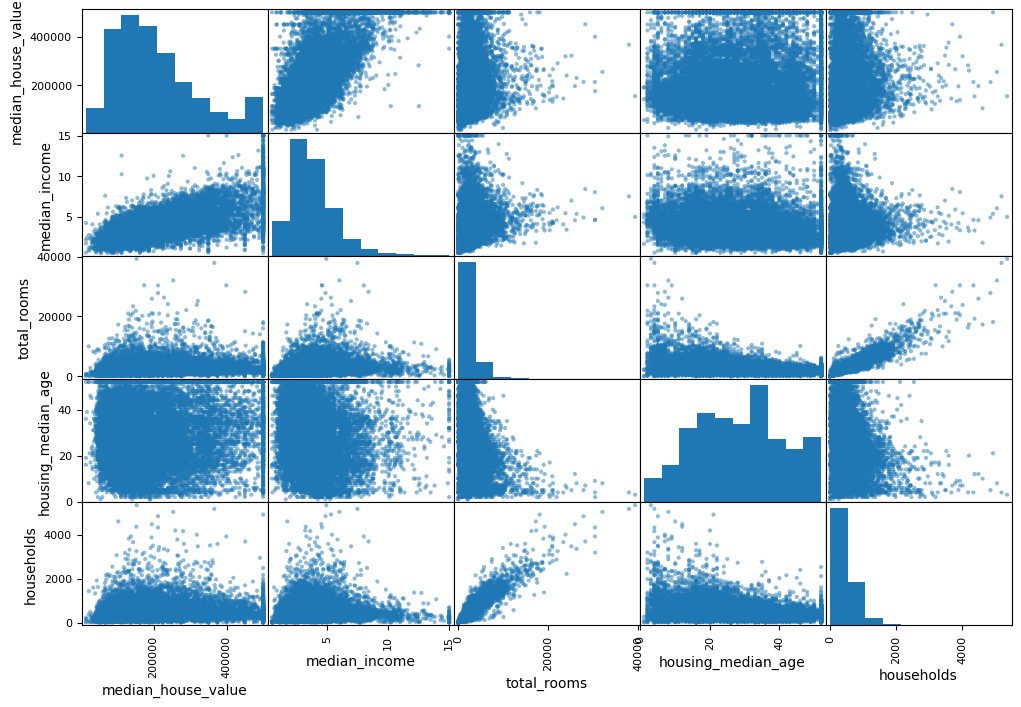

In [22]:
# Scatter de las variables más prometedoras
from pandas.plotting import scatter_matrix
attrs = ["median_house_value", "median_income", "total_rooms", "housing_median_age", "households"]
scatter_matrix(housing[attrs], figsize=(12, 8))
plt.show()

### 6. Conclusiones del Análisis Exploratorio

#### Tamaño y estructura de los datos
- Tenemos información de **16,512 distritos** de California
- Cada distrito tiene **10 características** como ubicación, número de habitaciones, ingreso promedio y precio de vivienda
- El precio de vivienda (`median_house_value`) es lo que queremos predecir

#### Problemas encontrados en los datos
- La columna de **número de cuartos** (`total_bedrooms`) tiene **168 registros vacíos** que hay que rellenar antes de usarlos
- El precio máximo registrado es exactamente **$500,001**, lo que indica que los datos fueron cortados artificialmente — los distritos más caros no muestran su precio real
- Algunas variables tienen valores extremos muy alejados del promedio, como la del `total_rooms`

#### Lo que muestra el mapa
- Las viviendas más caras están en la **Bahía de San Francisco** y la costa de **Los Ángeles**
- Los distritos del interior del estado son consistentemente más baratos
- La ubicación frente al océano tiene una influencia clara en el precio

#### Qué variables se relacionan más con el precio
- El **ingreso promedio del distrito** es lo que más se relaciona con el precio (0.69), lo que significa que a mayor ingreso de los residentes, mayor el valor de las casas
- La **latitud** tiene una relación negativa leve, lo que indica que los distritos más al norte tienden a ser más baratos
- La **población** prácticamente no tiene relación directa con el precio